# Bluesky Moderation — Full IAA & Precision/Recall Analysis
**NeurIPS Paper · MPI SWS**

Two surveys:
- **Main survey** (3K curated posts): Ines=800, adash=786, soumidas=100
- **Firehose survey** (1K random): Ines=1001, adash=806, soumidas=302

Bluesky official labeler used as **predicted**, human annotations as **ground truth** (firehose only).

## 1. Imports & Setup

In [169]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report)
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DISPLAY_NUM_OFFSET = 10000

ANN_PATH = "Bluesky Moderation Annotations.csv"
POSTS_MAIN = "combined_3k.jsonl"
POSTS_FH   = "firehose_1k_labeled.jsonl"

## 2. Load Data

In [170]:
ann = pd.read_csv(ANN_PATH)
ann.columns = ann.columns.str.strip()
print(f"Loaded {len(ann)} rows from CSV")
ann.head(3)

main_ann = ann[ann["display_num"] < 10000].copy()
fh_ann = ann[(ann["display_num"] >= 10000) & (ann["display_num"] < 20000)].copy()
fh_ann["display_num_norm"] = fh_ann["display_num"] - 10000
pilot_remaining_ann = ann[
    (ann["display_num"] >= 20000) & (ann["display_num"] < 30000)
].copy()
pilot_remaining_ann["display_num_norm"] = pilot_remaining_ann["display_num"] - 20000

print("=== MAIN SURVEY ===")
print(
    main_ann.groupby("annotator_name")
    .agg(
        posts=("post_id", "nunique"),
        min_dn=("display_num", "min"),
        max_dn=("display_num", "max"),
    )
    .to_string()
)

print("\n=== FIREHOSE SURVEY ===")
print(
    fh_ann.groupby("annotator_name")
    .agg(
        posts=("post_id", "nunique"),
        min_dn=("display_num_norm", "min"),
        max_dn=("display_num_norm", "max"),
    )
    .to_string()
)

print("\n=== PILOT REMAINING ===")
print(
    pilot_remaining_ann.groupby("annotator_name")
    .agg(
        posts=("post_id", "nunique"),
        min_dn=("display_num_norm", "min"),
        max_dn=("display_num_norm", "max"),
    )
    .to_string()
)

Loaded 4794 rows from CSV
=== MAIN SURVEY ===
                posts  min_dn  max_dn
annotator_name                       
Ines              800       1     800
adash             800       1     800
soumidas          100       1     100

=== FIREHOSE SURVEY ===
                posts  min_dn  max_dn
annotator_name                       
Ines             1000      17    1000
adash            1000       1    1000
soumidas          302       1     302

=== PILOT REMAINING ===
                posts  min_dn  max_dn
annotator_name                       
Ines              115       1     115
adash              83       1      83


In [126]:
def load_jsonl(path):
    posts = {}
    try:
        with open(path) as f:
            for line in f:
                if line.strip():
                    p = json.loads(line)
                    if p.get('uri'):
                        posts[p['uri']] = p
        print(f"Loaded {len(posts):,} posts — {path.split('/')[-1]}")
    except FileNotFoundError:
        print(f"NOT FOUND: {path}")
    return posts

main_posts = load_jsonl(POSTS_MAIN)
fh_posts   = load_jsonl(POSTS_FH)

# Join source to main annotations
main_ann['source'] = main_ann['post_id'].map(
    lambda u: main_posts.get(u,{}).get('source','unknown'))

# Join Bluesky labels to firehose annotations
fh_ann['bluesky_labels']  = fh_ann['post_id'].map(
    lambda u: fh_posts.get(u,{}).get('bluesky_labels', []))
fh_ann['bluesky_flagged'] = fh_ann['bluesky_labels'].apply(
    lambda x: 'Unsafe' if isinstance(x,list) and len(x)>0 else 'Safe')


Loaded 3,000 posts — combined_3k.jsonl
Loaded 1,000 posts — firehose_1k_labeled.jsonl


## 3. Helpers

In [127]:
def build_lookup(df, name):
    sub = df[df['annotator_name']==name]
    return dict(zip(sub['post_id'], sub['label']))

def iaa(common, lu_a, lu_b, name_a, name_b, label=''):
    la = [lu_a[p] for p in common]
    lb = [lu_b[p] for p in common]
    agree = sum(x==y for x,y in zip(la,lb))
    pct   = 100*agree/len(common)
    try:    kappa = cohen_kappa_score(la,lb)
    except: kappa = float('nan')
    interp = ('almost perfect' if kappa>=0.8 else 'substantial' if kappa>=0.6
              else 'moderate' if kappa>=0.4 else 'fair' if kappa>=0.2 else 'poor')
    tag = f' [{label}]' if label else ''
    print(f"  {name_a} vs {name_b}{tag}:  n={len(common)}  "
          f"agree={agree} ({pct:.1f}%)  κ={kappa:.3f} ({interp})")
    return dict(pair=f'{name_a} vs {name_b}', subset=label, n=len(common),
                pct=round(pct,1), kappa=round(kappa,3), interp=interp, la=la, lb=lb)

def cm_plot(axes_list, pairs, cmap='Blues', suptitle=''):
    for ax,(a,b,common,lad,lbd) in zip(axes_list, pairs):
        la2=[lad[p] for p in common]; lb2=[lbd[p] for p in common]
        k2=cohen_kappa_score(la2,lb2); ag2=sum(x==y for x,y in zip(la2,lb2))
        cats=['Safe','Unsafe']
        sns.heatmap(pd.DataFrame(confusion_matrix(la2,lb2,labels=cats),
                    index=[f'{a}: {c}' for c in cats],
                    columns=[f'{b}: {c}' for c in cats]),
                    annot=True,fmt='d',cmap=cmap,ax=ax,cbar=False,
                    linewidths=0.5,linecolor='white')
        ax.set_title(f'{a} vs {b}\nn={len(common)}  κ={k2:.2f}')
    if suptitle:
        plt.suptitle(suptitle, fontsize=12, y=1.02)


---
# Part A — Main Survey

## A1. Label Distribution

In [128]:
lu_m_ines  = build_lookup(main_ann,'Ines')
lu_m_adash = build_lookup(main_ann,'adash')
lu_m_soumi = build_lookup(main_ann,'soumidas')

dist = main_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist['total'] = dist.sum(axis=1)
dist['% unsafe'] = (dist.get('Unsafe',0)/dist['total']*100).round(1)
print(dist)


label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             599     201    800      25.1
adash            563     238    801      29.7
soumidas          68      32    100      32.0


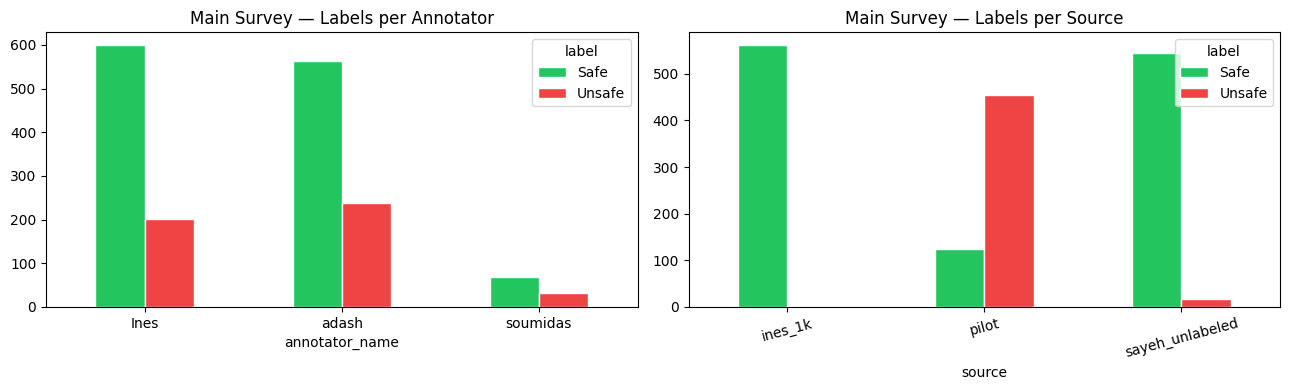

In [129]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
main_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0).plot(
    kind='bar',ax=axes[0],color=['#22c55e','#ef4444'],edgecolor='white')
axes[0].set_title('Main Survey — Labels per Annotator'); axes[0].tick_params(axis='x',rotation=0)

main_ann.groupby(['source','label']).size().unstack(fill_value=0).plot(
    kind='bar',ax=axes[1],color=['#22c55e','#ef4444'],edgecolor='white')
axes[1].set_title('Main Survey — Labels per Source'); axes[1].tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.savefig('main_label_dist.png',dpi=150,bbox_inches='tight'); plt.show()


## A2. Pairwise IAA

In [130]:
print("=== MAIN SURVEY — PAIRWISE IAA ===\n")
common_m_ia  = sorted(set(lu_m_ines) & set(lu_m_adash))
common_m_is  = sorted(set(lu_m_ines) & set(lu_m_soumi))
common_m_as  = sorted(set(lu_m_adash)& set(lu_m_soumi))
common_m_all = sorted(set(lu_m_ines) & set(lu_m_adash) & set(lu_m_soumi))

r_m_ia  = iaa(common_m_ia,  lu_m_ines, lu_m_adash,'Ines','adash')
r_m_is  = iaa(common_m_is,  lu_m_ines, lu_m_soumi,'Ines','soumidas')
r_m_as  = iaa(common_m_as,  lu_m_adash,lu_m_soumi,'adash','soumidas')
print(f"\n  All 3 overlap: {len(common_m_all)} posts")
if common_m_all:
    iaa(common_m_all, lu_m_ines, lu_m_adash,'Ines','adash','all3-subset')


=== MAIN SURVEY — PAIRWISE IAA ===

  Ines vs adash:  n=800  agree=738 (92.2%)  κ=0.806 (almost perfect)
  Ines vs soumidas:  n=100  agree=90 (90.0%)  κ=0.754 (substantial)
  adash vs soumidas:  n=100  agree=95 (95.0%)  κ=0.882 (almost perfect)

  All 3 overlap: 100 posts
  Ines vs adash [all3-subset]:  n=100  agree=93 (93.0%)  κ=0.821 (almost perfect)


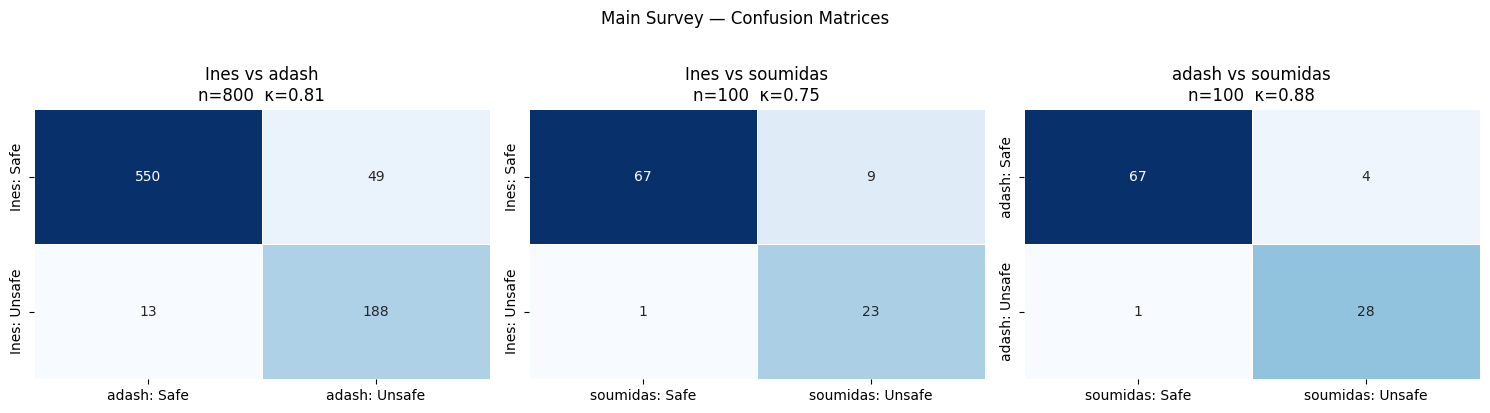

In [131]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
cm_plot(axes,[('Ines','adash',common_m_ia,lu_m_ines,lu_m_adash),
              ('Ines','soumidas',common_m_is,lu_m_ines,lu_m_soumi),
              ('adash','soumidas',common_m_as,lu_m_adash,lu_m_soumi)],
        cmap='Blues', suptitle='Main Survey — Confusion Matrices')
plt.tight_layout(); plt.savefig('main_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## A3. IAA by Source (Ines vs adash)

In [132]:
SOURCES = ['ines_1k','sayeh_unlabeled','pilot']
print("=== MAIN SURVEY — IAA BY SOURCE (Ines vs adash) ===\n")
src_rows = []
for src in SOURCES:
    src_posts = [p for p in common_m_ia
                 if main_posts.get(p,{}).get('source','')==src]
    if src_posts:
        r = iaa(src_posts, lu_m_ines, lu_m_adash,'Ines','adash', src)
        src_rows.append({'Source':src,'n':r['n'],'Agreement (%)':r['pct'],
                         "Cohen's κ":r['kappa'],'Interpretation':r['interp']})
pd.DataFrame(src_rows)


=== MAIN SURVEY — IAA BY SOURCE (Ines vs adash) ===

  Ines vs adash [ines_1k]:  n=264  agree=264 (100.0%)  κ=nan (poor)
  Ines vs adash [sayeh_unlabeled]:  n=264  agree=261 (98.9%)  κ=0.764 (substantial)
  Ines vs adash [pilot]:  n=272  agree=213 (78.3%)  κ=0.379 (fair)


,Source,n,Agreement (%),Cohen's κ,Interpretation
0,ines_1k,264,100.0,NaN,poor
1,sayeh_unlabeled,264,98.9,0.764,substantial
2,pilot,272,78.3,0.379,fair


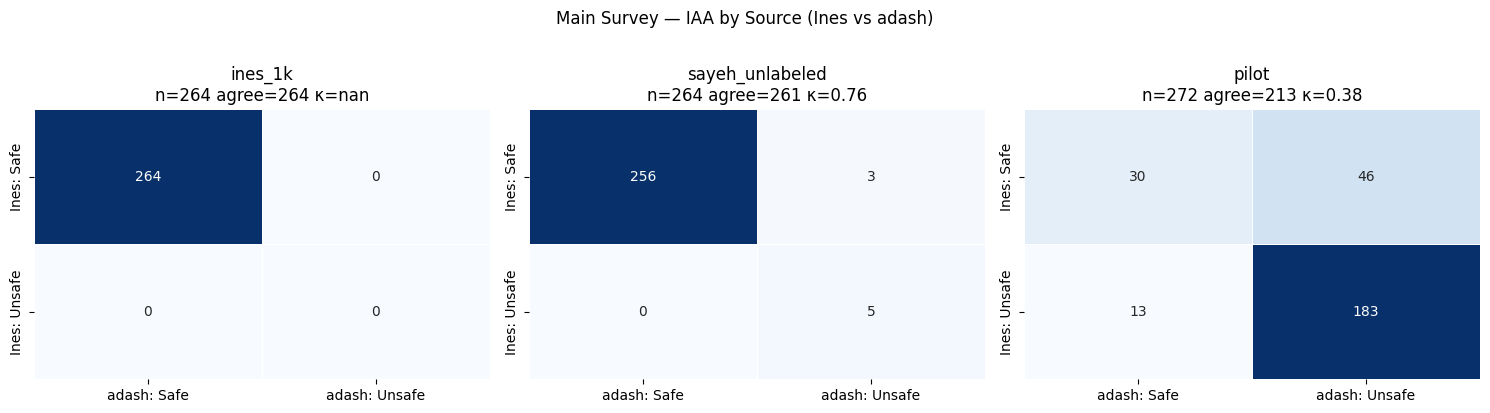

In [133]:
if src_rows:
    df_src = pd.DataFrame(src_rows)
    fig, axes = plt.subplots(1,len(SOURCES),figsize=(15,4))
    for ax,src in zip(axes,SOURCES):
        src_posts=[p for p in common_m_ia
                   if main_posts.get(p,{}).get('source','')==src]
        if not src_posts: continue
        la2=[lu_m_ines[p] for p in src_posts]; lb2=[lu_m_adash[p] for p in src_posts]
        k2=cohen_kappa_score(la2,lb2)
        cats=['Safe','Unsafe']
        sns.heatmap(pd.DataFrame(confusion_matrix(la2,lb2,labels=cats),
            index=[f'Ines: {c}' for c in cats],
            columns=[f'adash: {c}' for c in cats]),
            annot=True,fmt='d',cmap='Blues',ax=ax,cbar=False,
            linewidths=0.5,linecolor='white')
        ag2=sum(x==y for x,y in zip(la2,lb2))
        ax.set_title(f'{src}\nn={len(src_posts)} agree={ag2} κ={k2:.2f}')
    plt.suptitle('Main Survey — IAA by Source (Ines vs adash)',fontsize=12,y=1.02)
    plt.tight_layout(); plt.savefig('main_source_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## A4. Disagreements (Main)

In [ ]:
rows=[]
for p in common_m_ia:
    if lu_m_ines[p] != lu_m_adash[p]:
        rows.append({'source':main_posts.get(p,{}).get('source','?'),
                     'Ines':lu_m_ines[p],'adash':lu_m_adash[p],
                     'post_id':p[-35:],
                     'text':str(main_posts.get(p,{}).get('text',''))[:100]})
d_main = pd.DataFrame(rows)
print(f"Main disagreements (Ines vs adash): {len(d_main)}/{len(common_m_ia)} ({100*len(d_main)/len(common_m_ia):.1f}%)")
print("By source:"); print(d_main.groupby('source').size().to_string())
d_main.head(10)


---
# Part B — Firehose Survey

## B1. Label Distribution

In [134]:
lu_f_ines  = build_lookup(fh_ann,'Ines')
lu_f_adash = build_lookup(fh_ann,'adash')
lu_f_soumi = build_lookup(fh_ann,'soumidas')

dist_fh = fh_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist_fh['total']    = dist_fh.sum(axis=1)
dist_fh['% unsafe'] = (dist_fh.get('Unsafe',0)/dist_fh['total']*100).round(1)
print(dist_fh)

n_bsky = sum(1 for p in fh_posts.values() if p.get('bluesky_labels'))
print(f"\nBluesky flagged: {n_bsky}/{len(fh_posts)} ({100*n_bsky/len(fh_posts):.1f}%) of all firehose posts")


label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             981      20   1001       2.0
adash            963      40   1003       4.0
soumidas         269      33    302      10.9

Bluesky flagged: 6/1000 (0.6%) of all firehose posts


## B2. Step 1 — Ines vs adash IAA

In [135]:
print("=== FIREHOSE — INES vs ADASH ===\n")
common_f_ia = sorted(set(lu_f_ines) & set(lu_f_adash))
r_f_ia = iaa(common_f_ia, lu_f_ines, lu_f_adash,'Ines','adash')
print()
la=[lu_f_ines[p] for p in common_f_ia]; lb=[lu_f_adash[p] for p in common_f_ia]
print(classification_report(la,lb,target_names=['Safe','Unsafe']))


=== FIREHOSE — INES vs ADASH ===

  Ines vs adash:  n=1000  agree=969 (96.9%)  κ=0.460 (moderate)

              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98       980
      Unsafe       0.36      0.70      0.47        20

    accuracy                           0.97      1000
   macro avg       0.68      0.84      0.73      1000
weighted avg       0.98      0.97      0.97      1000



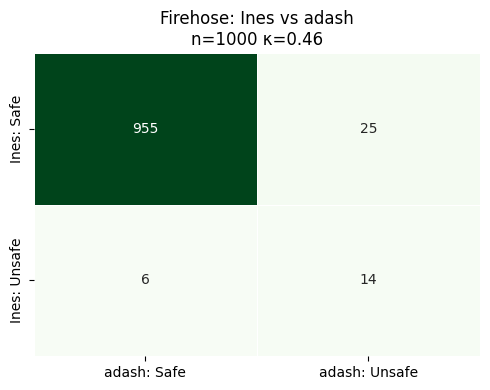

In [136]:
fig, ax = plt.subplots(figsize=(5,4))
la=[lu_f_ines[p] for p in common_f_ia]; lb=[lu_f_adash[p] for p in common_f_ia]
k=cohen_kappa_score(la,lb); cats=['Safe','Unsafe']
sns.heatmap(pd.DataFrame(confusion_matrix(la,lb,labels=cats),
    index=[f'Ines: {c}' for c in cats],
    columns=[f'adash: {c}' for c in cats]),
    annot=True,fmt='d',cmap='Greens',ax=ax,cbar=False,linewidths=0.5,linecolor='white')
ax.set_title(f'Firehose: Ines vs adash\nn={len(common_f_ia)} κ={k:.2f}')
plt.tight_layout(); plt.savefig('fh_ines_adash.png',dpi=150,bbox_inches='tight'); plt.show()


## B3. Step 2 — soumidas as Tiebreaker

In [137]:
print("=== FIREHOSE — WITH TIEBREAKER (soumidas) ===\n")
common_f_is  = sorted(set(lu_f_ines) & set(lu_f_soumi))
common_f_as  = sorted(set(lu_f_adash)& set(lu_f_soumi))
common_f_all = sorted(set(lu_f_ines) & set(lu_f_adash) & set(lu_f_soumi))

r_f_is = iaa(common_f_is,  lu_f_ines, lu_f_soumi,'Ines','soumidas')
r_f_as = iaa(common_f_as,  lu_f_adash,lu_f_soumi,'adash','soumidas')
print(f"\n  All 3 overlap: {len(common_f_all)} posts")
if common_f_all:
    iaa(common_f_all, lu_f_ines, lu_f_adash,'Ines','adash','all3-subset')

# How many Ines-adash disagreements did soumidas resolve?
disagree = [p for p in common_f_ia if lu_f_ines[p]!=lu_f_adash[p]]
soumi_on = [p for p in disagree if p in lu_f_soumi]
print(f"\n  Ines-adash disagreements: {len(disagree)}")
print(f"  soumidas labeled {len(soumi_on)} of those")
if soumi_on:
    sided = {'Ines':0,'adash':0,'neither':0}
    for p in soumi_on:
        s=lu_f_soumi[p]
        if s==lu_f_ines[p]: sided['Ines']+=1
        elif s==lu_f_adash[p]: sided['adash']+=1
        else: sided['neither']+=1
    print(f"  Sided with: {sided}")


=== FIREHOSE — WITH TIEBREAKER (soumidas) ===

  Ines vs soumidas:  n=302  agree=271 (89.7%)  κ=0.177 (poor)
  adash vs soumidas:  n=302  agree=275 (91.1%)  κ=0.363 (fair)

  All 3 overlap: 302 posts
  Ines vs adash [all3-subset]:  n=302  agree=290 (96.0%)  κ=0.315 (fair)

  Ines-adash disagreements: 31
  soumidas labeled 12 of those
  Sided with: {'Ines': 4, 'adash': 8, 'neither': 0}


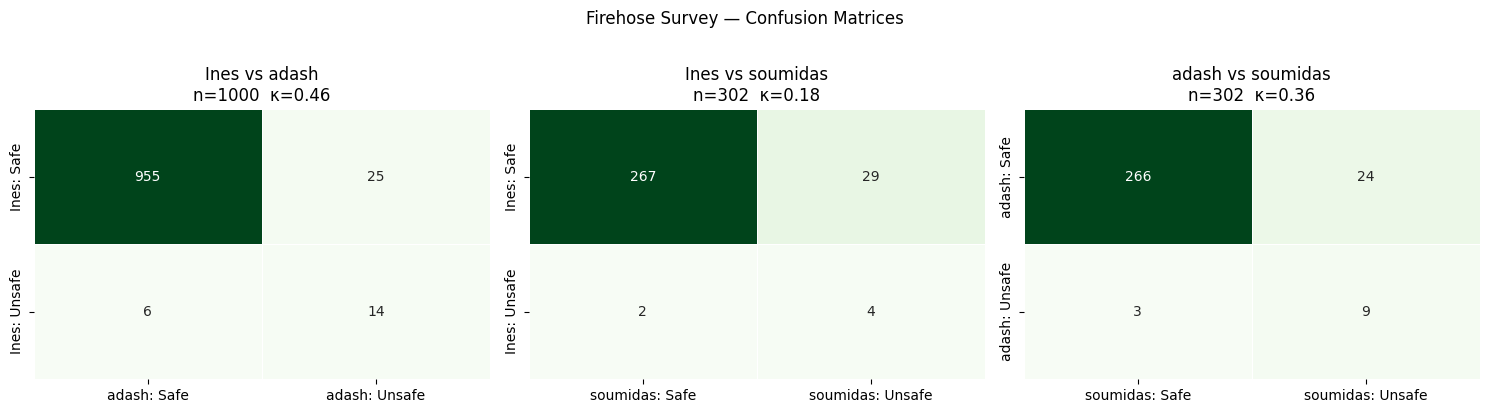

In [138]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
cm_plot(axes,[('Ines','adash',common_f_ia,lu_f_ines,lu_f_adash),
              ('Ines','soumidas',common_f_is,lu_f_ines,lu_f_soumi),
              ('adash','soumidas',common_f_as,lu_f_adash,lu_f_soumi)],
        cmap='Greens', suptitle='Firehose Survey — Confusion Matrices')
plt.tight_layout(); plt.savefig('fh_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


## B4. Majority Vote Label

In [139]:
mv = {}
if common_f_all:
    for p in common_f_all:
        votes=[lu_f_ines[p],lu_f_adash[p],lu_f_soumi[p]]
        mv[p]='Unsafe' if votes.count('Unsafe')>=2 else 'Safe'
    n_u=sum(1 for v in mv.values() if v=='Unsafe')
    print(f"Majority vote (n={len(mv)}): Unsafe={n_u} ({100*n_u/len(mv):.1f}%)  Safe={len(mv)-n_u} ({100*(len(mv)-n_u)/len(mv):.1f}%)")
    for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
        ag=sum(lu[p]==mv[p] for p in common_f_all)
        print(f"  {name} agrees with majority: {ag}/{len(common_f_all)} ({100*ag/len(common_f_all):.1f}%)")


Majority vote (n=302): Unsafe=10 (3.3%)  Safe=292 (96.7%)
  Ines agrees with majority: 294/302 (97.4%)
  adash agrees with majority: 298/302 (98.7%)
  soumidas agrees with majority: 279/302 (92.4%)


## B5. Precision & Recall vs Bluesky Labels

In [140]:
print("=== FIREHOSE — PRECISION/RECALL (Bluesky=predicted, Human=ground truth) ===\n")

all_fh_uris = sorted(set(lu_f_ines)|set(lu_f_adash)|set(lu_f_soumi))
n_bsky_total = sum(1 for u in all_fh_uris if fh_posts.get(u,{}).get('bluesky_labels'))
print(f"Base rates (all annotated posts, n={len(all_fh_uris)}):")
print(f"  Bluesky flagged: {n_bsky_total} ({100*n_bsky_total/len(all_fh_uris):.1f}%)")
for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
    n_u=sum(1 for v in lu.values() if v=='Unsafe')
    print(f"  {name} unsafe:   {n_u}/{len(lu)} ({100*n_u/len(lu):.1f}%)")


=== FIREHOSE — PRECISION/RECALL (Bluesky=predicted, Human=ground truth) ===

Base rates (all annotated posts, n=1000):
  Bluesky flagged: 6 (0.6%)
  Ines unsafe:   20/1000 (2.0%)
  adash unsafe:   39/1000 (3.9%)
  soumidas unsafe:   33/302 (10.9%)


In [141]:
pr_rows=[]
for name,lu in [('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]:
    sub=fh_ann[fh_ann['annotator_name']==name].copy()
    sub=sub[sub['post_id'].isin(lu)]
    y_true=sub['label'].map({'Safe':0,'Unsafe':1}).values
    y_pred=sub['bluesky_flagged'].map({'Safe':0,'Unsafe':1}).values
    p=precision_score(y_true,y_pred,zero_division=0)
    r=recall_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    n_bsky_f=y_pred.sum(); n_h_u=y_true.sum()
    n_both=((y_true==1)&(y_pred==1)).sum()
    n_only_bsky=((y_true==0)&(y_pred==1)).sum()
    n_only_human=((y_true==1)&(y_pred==0)).sum()
    print(f"{name} (n={len(y_true)}):")
    print(f"  Bluesky flagged: {n_bsky_f} ({100*n_bsky_f/len(y_true):.1f}%)  Human unsafe: {n_h_u} ({100*n_h_u/len(y_true):.1f}%)")
    print(f"  Both unsafe: {n_both}  Only Bluesky: {n_only_bsky}  Only Human: {n_only_human}")
    print(f"  Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}\n")
    pr_rows.append({'Annotator':name,'n':len(y_true),
                    'Bluesky (%)':round(100*n_bsky_f/len(y_true),1),
                    'Human unsafe (%)':round(100*n_h_u/len(y_true),1),
                    'Both':int(n_both),'Only Bsky':int(n_only_bsky),'Only Human':int(n_only_human),
                    'Precision':round(p,3),'Recall':round(r,3),'F1':round(f1,3)})

# Majority vote
if mv:
    y_true_mv=np.array([1 if mv[p]=='Unsafe' else 0 for p in common_f_all])
    y_pred_mv=np.array([1 if fh_posts.get(p,{}).get('bluesky_labels') else 0 for p in common_f_all])
    p=precision_score(y_true_mv,y_pred_mv,zero_division=0)
    r=recall_score(y_true_mv,y_pred_mv,zero_division=0)
    f1=f1_score(y_true_mv,y_pred_mv,zero_division=0)
    n_bsky_f=y_pred_mv.sum(); n_h_u=y_true_mv.sum()
    n_both=((y_true_mv==1)&(y_pred_mv==1)).sum()
    n_only_bsky=((y_true_mv==0)&(y_pred_mv==1)).sum()
    n_only_human=((y_true_mv==1)&(y_pred_mv==0)).sum()
    print(f"Majority vote (n={len(common_f_all)}):")
    print(classification_report(y_true_mv,y_pred_mv,target_names=['Safe','Unsafe']))
    pr_rows.append({'Annotator':'Majority vote','n':len(common_f_all),
                    'Bluesky (%)':round(100*n_bsky_f/len(common_f_all),1),
                    'Human unsafe (%)':round(100*n_h_u/len(common_f_all),1),
                    'Both':int(n_both),'Only Bsky':int(n_only_bsky),'Only Human':int(n_only_human),
                    'Precision':round(p,3),'Recall':round(r,3),'F1':round(f1,3)})

pr_df=pd.DataFrame(pr_rows)
pr_df


Ines (n=1001):
  Bluesky flagged: 6 (0.6%)  Human unsafe: 20 (2.0%)
  Both unsafe: 6  Only Bluesky: 0  Only Human: 14
  Precision: 1.000  Recall: 0.300  F1: 0.462

adash (n=1003):
  Bluesky flagged: 6 (0.6%)  Human unsafe: 40 (4.0%)
  Both unsafe: 6  Only Bluesky: 0  Only Human: 34
  Precision: 1.000  Recall: 0.150  F1: 0.261

soumidas (n=302):
  Bluesky flagged: 0 (0.0%)  Human unsafe: 33 (10.9%)
  Both unsafe: 0  Only Bluesky: 0  Only Human: 33
  Precision: 0.000  Recall: 0.000  F1: 0.000

Majority vote (n=302):
              precision    recall  f1-score   support

        Safe       0.97      1.00      0.98       292
      Unsafe       0.00      0.00      0.00        10

    accuracy                           0.97       302
   macro avg       0.48      0.50      0.49       302
weighted avg       0.93      0.97      0.95       302



,Annotator,n,Bluesky (%),Human unsafe (%),Both,Only Bsky,Only Human,Precision,Recall,F1
0,Ines,1001,0.6,2.0,6,0,14,1.0,0.30,0.462
1,adash,1003,0.6,4.0,6,0,34,1.0,0.15,0.261
2,soumidas,302,0.0,10.9,0,0,33,0.0,0.00,0.000
3,Majority vote,302,0.0,3.3,0,0,10,0.0,0.00,0.000


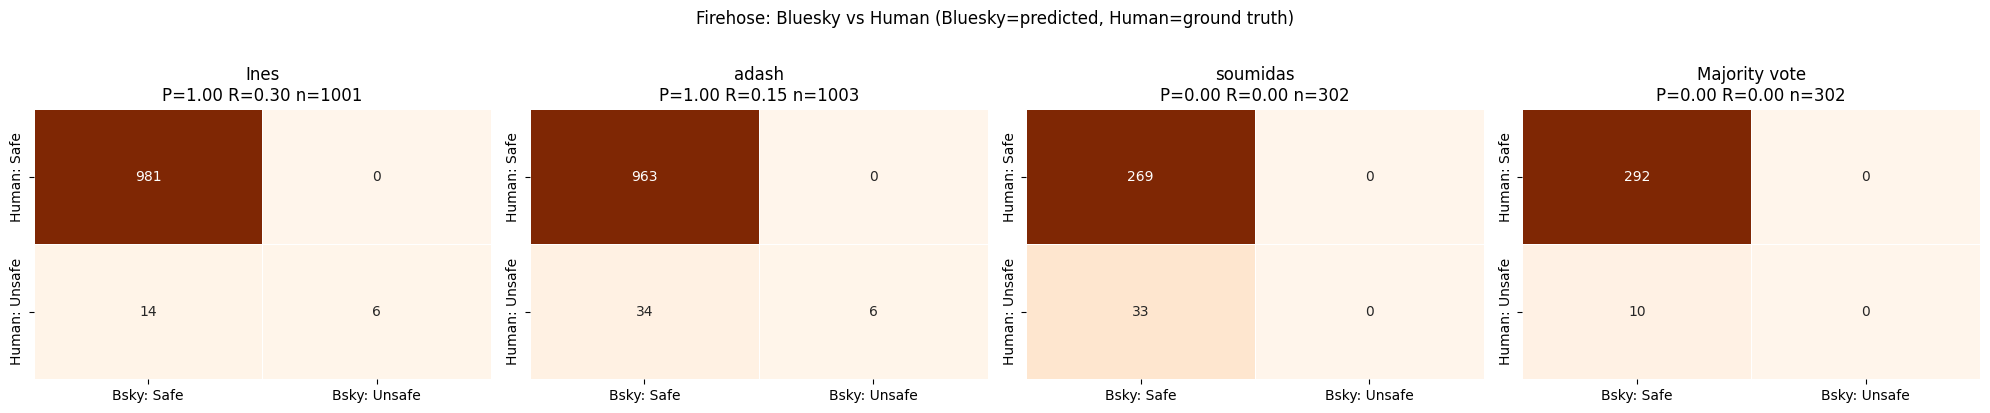

In [142]:
# Confusion matrices: Bluesky vs each annotator + majority vote
combos=[('Ines',lu_f_ines),('adash',lu_f_adash),('soumidas',lu_f_soumi)]
if mv: combos.append(('Majority vote',mv))
fig,axes=plt.subplots(1,len(combos),figsize=(5*len(combos),4))
for ax,(name,lu) in zip(axes,combos):
    if name=='Majority vote':
        posts=common_f_all; y_t=[1 if lu[p]=='Unsafe' else 0 for p in posts]
    else:
        sub=fh_ann[fh_ann['annotator_name']==name]
        posts=list(sub['post_id']); y_t=sub['label'].map({'Safe':0,'Unsafe':1}).tolist()
    y_p=[1 if fh_posts.get(p,{}).get('bluesky_labels') else 0 for p in posts]
    p_s=precision_score(y_t,y_p,zero_division=0); r_s=recall_score(y_t,y_p,zero_division=0)
    sns.heatmap(pd.DataFrame(confusion_matrix(y_t,y_p,labels=[0,1]),
        index=['Human: Safe','Human: Unsafe'],
        columns=['Bsky: Safe','Bsky: Unsafe']),
        annot=True,fmt='d',cmap='Oranges',ax=ax,cbar=False,linewidths=0.5,linecolor='white')
    ax.set_title(f'{name}\nP={p_s:.2f} R={r_s:.2f} n={len(posts)}')
plt.suptitle('Firehose: Bluesky vs Human (Bluesky=predicted, Human=ground truth)',fontsize=12,y=1.02)
plt.tight_layout(); plt.savefig('fh_pr_confusion.png',dpi=150,bbox_inches='tight'); plt.show()


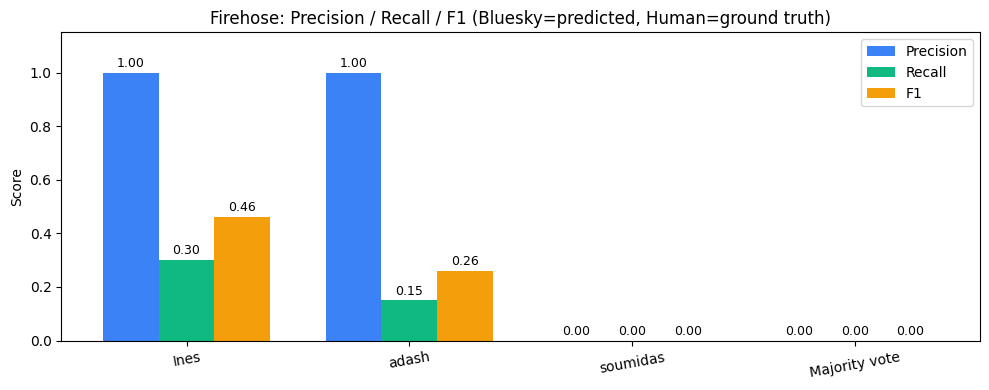

In [143]:
# Bar chart summary
fig,ax=plt.subplots(figsize=(10,4))
x=np.arange(len(pr_df)); w=0.25
ax.bar(x-w,pr_df['Precision'],w,label='Precision',color='#3b82f6')
ax.bar(x,  pr_df['Recall'],   w,label='Recall',   color='#10b981')
ax.bar(x+w,pr_df['F1'],       w,label='F1',       color='#f59e0b')
for i,row in pr_df.iterrows():
    for val,off in [(row['Precision'],-w),(row['Recall'],0),(row['F1'],w)]:
        ax.text(i+off,val+0.01,f'{val:.2f}',ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(pr_df['Annotator'],rotation=10)
ax.set_ylim(0,1.15); ax.set_ylabel('Score')
ax.set_title('Firehose: Precision / Recall / F1 (Bluesky=predicted, Human=ground truth)')
ax.legend(); plt.tight_layout()
plt.savefig('fh_pr_bar.png',dpi=150,bbox_inches='tight'); plt.show()


---
# Summary Table for Paper

In [144]:
rows=[
    ['Main','Ines vs adash',   len(common_m_ia), r_m_ia['pct'], r_m_ia['kappa'], r_m_ia['interp'],'—','—','—'],
    ['Main','Ines vs soumidas',len(common_m_is), r_m_is['pct'], r_m_is['kappa'], r_m_is['interp'],'—','—','—'],
    ['Main','adash vs soumidas',len(common_m_as),r_m_as['pct'], r_m_as['kappa'], r_m_as['interp'],'—','—','—'],
    ['Firehose','Ines vs adash',   len(common_f_ia), r_f_ia['pct'], r_f_ia['kappa'], r_f_ia['interp'],
     pr_df[pr_df['Annotator']=='Ines']['Precision'].values[0],
     pr_df[pr_df['Annotator']=='Ines']['Recall'].values[0],
     pr_df[pr_df['Annotator']=='Ines']['F1'].values[0]],
    ['Firehose','Ines vs soumidas',len(common_f_is), r_f_is['pct'], r_f_is['kappa'], r_f_is['interp'],'—','—','—'],
    ['Firehose','adash vs soumidas',len(common_f_as),r_f_as['pct'], r_f_as['kappa'], r_f_as['interp'],'—','—','—'],
]
cols=['Survey','Pair','n','Agreement (%)','Cohen κ','Interpretation',
      'Precision (Bsky)','Recall (Bsky)','F1 (Bsky)']
summary=pd.DataFrame(rows,columns=cols)
print(summary.to_string(index=False))
summary


  Survey              Pair    n  Agreement (%)  Cohen κ Interpretation Precision (Bsky) Recall (Bsky) F1 (Bsky)
    Main     Ines vs adash  800           92.2    0.806 almost perfect                —             —         —
    Main  Ines vs soumidas  100           90.0    0.754    substantial                —             —         —
    Main adash vs soumidas  100           95.0    0.882 almost perfect                —             —         —
Firehose     Ines vs adash 1000           96.9    0.460       moderate              1.0           0.3     0.462
Firehose  Ines vs soumidas  302           89.7    0.177           poor                —             —         —
Firehose adash vs soumidas  302           91.1    0.363           fair                —             —         —


,Survey,Pair,n,Agreement (%),Cohen κ,Interpretation,Precision (Bsky),Recall (Bsky),F1 (Bsky)
0,Main,Ines vs adash,800,92.2,0.806,almost perfect,—,—,—
1,Main,Ines vs soumidas,100,90.0,0.754,substantial,—,—,—
2,Main,adash vs soumidas,100,95.0,0.882,almost perfect,—,—,—
3,Firehose,Ines vs adash,1000,96.9,0.460,moderate,1.0,0.3,0.462
4,Firehose,Ines vs soumidas,302,89.7,0.177,poor,—,—,—
5,Firehose,adash vs soumidas,302,91.1,0.363,fair,—,—,—


## B6. Firehose Disagreement Sheet

In [145]:
# ── Firehose disagreement sheet (Ines vs adash, full 1K) ─────────────────────
print("=== FIREHOSE DISAGREEMENT SHEET ===\n")

disagree_f = [p for p in common_f_ia if lu_f_ines[p] != lu_f_adash[p]]
print(f"Total disagreements: {len(disagree_f)} / {len(common_f_ia)} ({100*len(disagree_f)/len(common_f_ia):.1f}%)")

cats_f_ines    = dict(zip(fh_ann[fh_ann['annotator_name']=='Ines']['post_id'],
                          fh_ann[fh_ann['annotator_name']=='Ines']['unsafe_categories'].fillna('')))
cats_f_adash   = dict(zip(fh_ann[fh_ann['annotator_name']=='adash']['post_id'],
                          fh_ann[fh_ann['annotator_name']=='adash']['unsafe_categories'].fillna('')))
reason_f_ines  = dict(zip(fh_ann[fh_ann['annotator_name']=='Ines']['post_id'],
                           fh_ann[fh_ann['annotator_name']=='Ines']['reason'].fillna('')))
reason_f_adash = dict(zip(fh_ann[fh_ann['annotator_name']=='adash']['post_id'],
                           fh_ann[fh_ann['annotator_name']=='adash']['reason'].fillna('')))

rows = []
for p in disagree_f:
    post  = fh_posts.get(p, {})
    bsky  = post.get('bluesky_labels', [])

    # Extract image URLs
    imgs = post.get('images') or []
    img_urls = []
    for item in imgs:
        if isinstance(item, dict):
            url = item.get('file') or item.get('url') or ''
        else:
            url = str(item)
        if url and url.lower() not in ('nan','none',''):
            img_urls.append(url)
    # Also check single "image" field
    single = post.get('image','')
    if single and single.lower() not in ('nan','none','') and single not in img_urls:
        img_urls.append(single)

    rows.append({
        'uri':              p,
        'text':             str(post.get('text',''))[:300],
        'Ines_label':       lu_f_ines[p],
        'Ines_categories':  cats_f_ines.get(p,''),
        'Ines_reason':      reason_f_ines.get(p,''),
        'adash_label':      lu_f_adash[p],
        'adash_categories': cats_f_adash.get(p,''),
        'adash_reason':     reason_f_adash.get(p,''),
        'bluesky_labels':   ','.join(bsky) if bsky else '',
        'bluesky_flagged':  'Yes' if bsky else 'No',
        'image_1':          img_urls[0] if len(img_urls) > 0 else '',
        'image_2':          img_urls[1] if len(img_urls) > 1 else '',
        'image_3':          img_urls[2] if len(img_urls) > 2 else '',
        'image_4':          img_urls[3] if len(img_urls) > 3 else '',
        'video':            str(post.get('video','')) if post.get('video') else '',
    })

disagree_df = pd.DataFrame(rows)
disagree_df.to_csv('firehose_disagreements.csv', index=False)
print(f"Saved {len(disagree_df)} rows → firehose_disagreements.csv")

print("\nBreakdown (Ines → adash):")
print(disagree_df.groupby(['Ines_label','adash_label']).size().to_string())

print("\nBluesky agrees with:")
def bsky_side(row):
    if not row['bluesky_flagged'] == 'Yes':
        return 'neither (safe)'
    if row['Ines_label'] == 'Unsafe':
        return 'Ines'
    if row['adash_label'] == 'Unsafe':
        return 'adash'
    return 'neither'
disagree_df['bsky_sides_with'] = disagree_df.apply(bsky_side, axis=1)
print(disagree_df['bsky_sides_with'].value_counts().to_string())

disagree_df.head(10)


=== FIREHOSE DISAGREEMENT SHEET ===

Total disagreements: 31 / 1000 (3.1%)
Saved 31 rows → firehose_disagreements.csv

Breakdown (Ines → adash):
Ines_label  adash_label
Safe        Unsafe         25
Unsafe      Safe            6

Bluesky agrees with:
bsky_sides_with
neither (safe)    31


,uri,text,Ines_label,Ines_categories,Ines_reason,adash_label,adash_categories,adash_reason,bluesky_labels,bluesky_flagged,image_1,image_2,image_3,image_4,video,bsky_sides_with
0,at://did:plc:34wf56u74h63txzhvnfgs5co/app.bsky.feed.post/3m3uhhlv65c2c,The Bible condemns all types of heterosexual relationships in the exact same...,Safe,,safe,Unsafe,S6,Intolerant toward sex before marriage and homosexual sex.,,No,,,,,,neither (safe)
1,at://did:plc:3lslcswuwmyvomqq3c54lous/app.bsky.feed.post/3ltazqx3ay22c,"Unfortunately, this Generation of Israel. Is about to get, North Korean styl...",Safe,,safe,Unsafe,S6,It is demeaning to all the citizens of a country.,,No,,,,,,neither (safe)
2,at://did:plc:3mip3yr6kqe643fqiwky6v5c/app.bsky.feed.post/3m6pcxebc5s2j,,Unsafe,S3,sexual figurative,Safe,,NA.,,No,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...,,,,,neither (safe)
3,at://did:plc:4cgrxzsjvivgyvk5kqjtq7ry/app.bsky.feed.post/3loicn4bkuk2d,I am against any type of violence or discrimination. But i am NOT going to s...,Safe,,safe,Unsafe,S6,Political opinion. Singling out Jew community is the problem.,,No,,,,,,neither (safe)
4,at://did:plc:4o72o7wyypk7xws6yiw2fhhn/app.bsky.feed.post/3m3aucfwggs2c,"Yes, it's likely is",Unsafe,S3,sexual figurative,Safe,,Did not understand the image fully.,,No,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...,,,,,neither (safe)
5,at://did:plc:4rwh3mq6q7hg2px5rgqhrjkd/app.bsky.feed.post/3m6lg5tn6s22a,"""You won't need food when you're BURNING IN HELL! Don't forget..God loves yo...",Unsafe,S6,hate against christians,Safe,,It seems like criticism but does not seem to violate the guidelines.,,No,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...,,,,,neither (safe)
6,at://did:plc:6hwfensjm4u6apznkorudjtq/app.bsky.feed.post/3lqpyw2gj3c2r,The wife is watching shit tv. It's either abuse you or have a wank\n\nI've d...,Safe,,safe,Unsafe,S2,Seems sexual.,,No,,,,,,neither (safe)
7,at://did:plc:7t7hsf4hvvloo66qgccb5kt2/app.bsky.feed.post/3lovwrebzvs2e,Are you Jewish? Or are you weaponizing our existence against someone?\n\nBec...,Safe,,safe,Unsafe,S8,I am leaning slightly toward rude because it is pointed toward someone and u...,,No,,,,,,neither (safe)
8,at://did:plc:en2viimzc3gydsljf42jbm5j/app.bsky.feed.post/3maa5wkd3tk2m,I remember when there was a mass shooting and a POTUS would try to comfort t...,Safe,,safe,Unsafe,S8,"This is a criticism, but it has gone a bit above the threshold calling the P...",,No,,,,,,neither (safe)
9,at://did:plc:ff3znuraxaizwmjm3xbbbwia/app.bsky.feed.post/3lx5x5zdjdk23,"If women are so strong and terrible, then why are feminists constantly tryin...",Safe,,personal opinion doesnt reach threshold of rude,Unsafe,S6,"mocking women, also insulting and rude.",,No,,,,,,neither (safe)


---
## B7. Post-Discussion Stats & Remaining Disagreements

In [146]:
import pandas as pd, json
from sklearn.metrics import cohen_kappa_score

DISAGREE_PATH = "firehose_disagreements_discussion.csv"  # updated CSV after discussion
POSTS_FH_PATH = "firehose_1k_labeled.jsonl"

df = pd.read_csv(DISAGREE_PATH)
df['Ines_label']  = df['Ines_label'].str.strip().str.capitalize()
df['adash_label'] = df['adash_label'].str.strip().str.capitalize()

# Load posts for media info
fh_posts_local = {}
try:
    with open(POSTS_FH_PATH) as f:
        for line in f:
            if line.strip():
                p = json.loads(line)
                if p.get('uri'): fh_posts_local[p['uri']] = p
except: pass

print(f"Total posts reviewed in discussion: {len(df)}")

now_agree     = df[df['Ines_label'] == df['adash_label']]
still_disagree = df[df['Ines_label'] != df['adash_label']]

print(f"Now agree after discussion: {len(now_agree)} ({100*len(now_agree)/len(df):.1f}%)")
print(f"Still disagreeing:          {len(still_disagree)} ({100*len(still_disagree)/len(df):.1f}%)")

print("\nLabel pairs after discussion:")
print(df.groupby(['Ines_label','adash_label']).size().unstack(fill_value=0).to_string())

# Cohen's kappa after discussion
kappa_after = cohen_kappa_score(df['Ines_label'], df['adash_label'])
agree_after = (df['Ines_label'] == df['adash_label']).sum()
print(f"\nAgreement after discussion: {agree_after}/{len(df)} ({100*agree_after/len(df):.1f}%)")
print(f"Cohen's κ after discussion: {kappa_after:.3f}")

# Compare to before (original disagreements = 0% agreement by definition)
print(f"\nImprovement: {len(now_agree)} posts resolved through discussion")

Total posts reviewed in discussion: 31
Now agree after discussion: 21 (67.7%)
Still disagreeing:          10 (32.3%)

Label pairs after discussion:
adash_label  Safe  Unsafe
Ines_label               
Safe           15       7
Unsafe          3       6

Agreement after discussion: 21/31 (67.7%)
Cohen's κ after discussion: 0.308

Improvement: 21 posts resolved through discussion


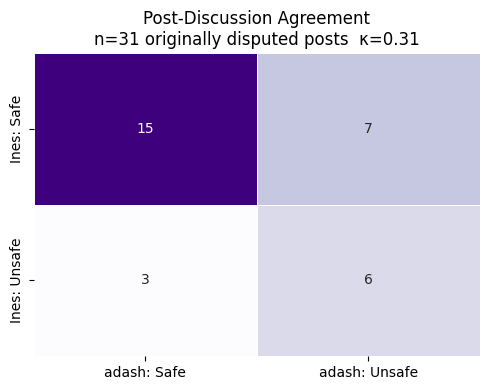

In [147]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(5,4))
cats = ['Safe','Unsafe']
cm = confusion_matrix(df['Ines_label'], df['adash_label'], labels=cats)
sns.heatmap(pd.DataFrame(cm,
    index=[f'Ines: {c}' for c in cats],
    columns=[f'adash: {c}' for c in cats]),
    annot=True, fmt='d', cmap='Purples', ax=ax, cbar=False,
    linewidths=0.5, linecolor='white')
kappa = cohen_kappa_score(df['Ines_label'], df['adash_label'])
ax.set_title(f'Post-Discussion Agreement\nn={len(df)} originally disputed posts  κ={kappa:.2f}')
plt.tight_layout()
plt.savefig('post_discussion_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


In [148]:
# Still disagreeing — full detail table for tiebreaker survey
print(f"Posts still needing tiebreaker: {len(still_disagree)}\n")
cols = ['uri','text','Ines_label','adash_label','bluesky_flagged',
        'Ines_reason','adash_reason','image_1','video']
print(still_disagree[cols].to_string())

# Save for tiebreaker survey upload
still_disagree.to_csv('firehose_still_disagree.csv', index=False)
print(f"\nSaved → firehose_still_disagree.csv")


Posts still needing tiebreaker: 10

                                                                       uri                                                                                                                                                                     text Ines_label adash_label bluesky_flagged                                  Ines_reason                                                                                                                                                           adash_reason                                                                                                                                                                     image_1 video
3   at://did:plc:4cgrxzsjvivgyvk5kqjtq7ry/app.bsky.feed.post/3loicn4bkuk2d  I am against any type of violence or discrimination. But i am NOT going to support ANY member of the Jew community who shows support of symphaty for the Israel  State.       Safe      Unsafe              No         

---
# Updated Analysis with New CSV

In [152]:
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             cohen_kappa_score, confusion_matrix,
                             classification_report)

ANN_PATH = "Bluesky Moderation Annotations - Sheet1 (2).csv"
POSTS_MAIN    = "combined_3k.jsonl"
POSTS_FH      = "firehose_1k_labeled.jsonl"
POSTS_AUTOMOD = "automod_unflagged_samples.jsonl"
DISAGREE_PATH = "firehose_disagreements_discussion.csv"
LABELER_FILE  = None

ann = pd.read_csv(ANN_PATH)
ann.columns = ann.columns.str.strip()
ann = ann.drop_duplicates(subset=['annotator_name','post_id'], keep='last')

main_ann   = ann[ann['display_num'] < 10000].copy()
fh_ann     = ann[(ann['display_num'] >= 10000) & (ann['display_num'] < 20000)].copy()
automod_ann= ann[ann['display_num'] >= 40000].copy()

print(f"Main:     {main_ann.groupby('annotator_name').size().to_dict()}")
print(f"Firehose: {fh_ann.groupby('annotator_name').size().to_dict()}")
print(f"Automod:  {automod_ann.groupby('annotator_name').size().to_dict()}")

def load_jsonl(path):
    posts = {}
    try:
        with open(path) as f:
            for line in f:
                if line.strip():
                    p = json.loads(line)
                    if p.get('uri'): posts[p['uri']] = p
        print(f"Loaded {len(posts):,} — {path.split('/')[-1]}")
    except FileNotFoundError:
        print(f"NOT FOUND: {path}")
    return posts

main_posts   = load_jsonl(POSTS_MAIN)
fh_posts     = load_jsonl(POSTS_FH)
automod_posts= load_jsonl(POSTS_AUTOMOD)

def build_lookup(df, name):
    sub = df[df['annotator_name']==name].drop_duplicates('post_id', keep='last')
    return dict(zip(sub['post_id'], sub['label']))

Main:     {'Ines': 800, 'adash': 800, 'soumidas': 100}
Firehose: {'Ines': 1000, 'adash': 1000, 'soumidas': 302}
Automod:  {'Ines': 288, 'adash': 288}
Loaded 3,000 — combined_3k.jsonl
Loaded 1,000 — firehose_1k_labeled.jsonl
Loaded 288 — automod_unflagged_samples.jsonl


---
# Task 1 — Pilot Set: Precision per Bluesky Label

Bluesky labels = predicted, Human labels = ground truth.
For each Bluesky label category, what fraction of posts humans confirmed as Unsafe?

In [156]:
# ── Task 1 — Pilot Set: Precision per Bluesky Label ──────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

# Load pilot_1k — all posts have a Bluesky label
pilot_posts = {}
with open("pilot_1k.jsonl") as f:
    for line in f:
        if line.strip():
            p = json.loads(line)
            if p.get("uri"):
                pilot_posts[p["uri"]] = p

print(f"Pilot posts loaded: {len(pilot_posts):,}")
print("All have Bluesky labels (unsafe-only sample)")

# Join to main_ann
pilot_ann = main_ann[main_ann["post_id"].isin(pilot_posts)].copy()
pilot_ann["bsky_label"] = pilot_ann["post_id"].map(
    lambda u: pilot_posts.get(u, {}).get("label", "") or ""
)

print(f"\nPilot annotations found: {len(pilot_ann)}")
print(pilot_ann.groupby("annotator_name").size().to_string())

print("\nBluesky label distribution in annotated posts:")
print(pilot_ann["bsky_label"].value_counts().to_string())

Pilot posts loaded: 1,000
All have Bluesky labels (unsafe-only sample)

Pilot annotations found: 578
annotator_name
Ines        272
adash       272
soumidas     34

Bluesky label distribution in annotated posts:
bsky_label
intolerant           78
porn                 76
graphic-media        73
threat               66
self-harm            61
sexual-figurative    60
nudity               60
rude                 53
sexual               51


In [157]:
# ── Recall: all posts are Bluesky-flagged, human=ground truth ────────────────
print("=== PILOT RECALL (all posts Bluesky-labeled) ===\n")
print("Note: pilot_1k is 100% Bluesky-flagged unsafe posts.")
print("Recall = fraction humans confirmed as Unsafe.\n")

recall_rows = []
for name in ["Ines", "adash"]:
    sub = pilot_ann[pilot_ann["annotator_name"] == name].copy()
    if len(sub) == 0:
        continue
    n_total = len(sub)
    n_unsafe = (sub["label"] == "Unsafe").sum()
    n_safe = n_total - n_unsafe
    recall = n_unsafe / n_total

    print(f"{name} (n={n_total}):")
    print(f"  Confirmed Unsafe: {n_unsafe:>4} ({100*n_unsafe/n_total:.1f}%)")
    print(
        f"  Labeled Safe:     {n_safe:>4} ({100*n_safe/n_total:.1f}%)  ← Bluesky false positives"
    )
    print(f"  Recall:           {recall:.3f}\n")
    recall_rows.append(
        {
            "Annotator": name,
            "n": n_total,
            "Confirmed Unsafe": int(n_unsafe),
            "Labeled Safe": int(n_safe),
            "Recall": round(recall, 3),
        }
    )

pd.DataFrame(recall_rows)

=== PILOT RECALL (all posts Bluesky-labeled) ===

Note: pilot_1k is 100% Bluesky-flagged unsafe posts.
Recall = fraction humans confirmed as Unsafe.

Ines (n=272):
  Confirmed Unsafe:  196 (72.1%)
  Labeled Safe:       76 (27.9%)  ← Bluesky false positives
  Recall:           0.721

adash (n=272):
  Confirmed Unsafe:  229 (84.2%)
  Labeled Safe:       43 (15.8%)  ← Bluesky false positives
  Recall:           0.842



,Annotator,n,Confirmed Unsafe,Labeled Safe,Recall
0,Ines,272,196,76,0.721
1,adash,272,229,43,0.842


In [158]:
# ── Precision per Bluesky label category ─────────────────────────────────────
print("=== PILOT PRECISION PER BLUESKY LABEL CATEGORY ===\n")
print("Precision = of posts Bluesky tagged with label X,")
print("what fraction did humans label as Unsafe?\n")

all_labels = sorted(pilot_ann["bsky_label"].dropna().unique())
all_labels = [l for l in all_labels if l]

rows = []
for name in ["Ines", "adash"]:
    sub = pilot_ann[pilot_ann["annotator_name"] == name]
    if len(sub) == 0:
        continue
    for lbl in all_labels:
        tagged = sub[sub["bsky_label"] == lbl]
        if len(tagged) == 0:
            continue
        n_unsafe = (tagged["label"] == "Unsafe").sum()
        n_safe = len(tagged) - n_unsafe
        prec = n_unsafe / len(tagged)
        rows.append(
            {
                "Annotator": name,
                "Bluesky label": lbl,
                "n": len(tagged),
                "Confirmed Unsafe": int(n_unsafe),
                "Labeled Safe": int(n_safe),
                "Precision": round(prec, 3),
            }
        )
        print(
            f"  [{name}] {lbl:<22} n={len(tagged):>3}  "
            f"unsafe={n_unsafe:>3}  safe={n_safe:>3}  precision={prec:.3f}"
        )

prec_df = pd.DataFrame(rows)
print(f"\nOverall mean precision:")
print(
    prec_df.groupby("Annotator")["Precision"]
    .agg(["mean", "min", "max"])
    .round(3)
    .to_string()
)
prec_df

=== PILOT PRECISION PER BLUESKY LABEL CATEGORY ===

Precision = of posts Bluesky tagged with label X,
what fraction did humans label as Unsafe?

  [Ines] graphic-media          n= 33  unsafe= 26  safe=  7  precision=0.788
  [Ines] intolerant             n= 37  unsafe= 20  safe= 17  precision=0.541
  [Ines] nudity                 n= 28  unsafe= 27  safe=  1  precision=0.964
  [Ines] porn                   n= 35  unsafe= 35  safe=  0  precision=1.000
  [Ines] rude                   n= 25  unsafe=  6  safe= 19  precision=0.240
  [Ines] self-harm              n= 28  unsafe= 18  safe= 10  precision=0.643
  [Ines] sexual                 n= 24  unsafe= 19  safe=  5  precision=0.792
  [Ines] sexual-figurative      n= 29  unsafe= 26  safe=  3  precision=0.897
  [Ines] threat                 n= 33  unsafe= 19  safe= 14  precision=0.576
  [adash] graphic-media          n= 33  unsafe= 25  safe=  8  precision=0.758
  [adash] intolerant             n= 37  unsafe= 31  safe=  6  precision=0.838
  [ada

,Annotator,Bluesky label,n,Confirmed Unsafe,Labeled Safe,Precision
0,Ines,graphic-media,33,26,7,0.788
1,Ines,intolerant,37,20,17,0.541
2,Ines,nudity,28,27,1,0.964
3,Ines,porn,35,35,0,1.000
4,Ines,rude,25,6,19,0.240
5,Ines,self-harm,28,18,10,0.643
6,Ines,sexual,24,19,5,0.792
7,Ines,sexual-figurative,29,26,3,0.897
8,Ines,threat,33,19,14,0.576
9,adash,graphic-media,33,25,8,0.758


In [159]:
# ── IAA on pilot (Ines vs adash) ─────────────────────────────────────────────
lu_p_ines = build_lookup(pilot_ann, "Ines")
lu_p_adash = build_lookup(pilot_ann, "adash")
common_p = sorted(set(lu_p_ines) & set(lu_p_adash))

if common_p:
    la = [lu_p_ines[p] for p in common_p]
    lb = [lu_p_adash[p] for p in common_p]
    agree = sum(x == y for x, y in zip(la, lb))
    kappa = cohen_kappa_score(la, lb)
    print(f"Pilot IAA (n={len(common_p)}):")
    print(f"  Agreement: {agree}/{len(common_p)} ({100*agree/len(common_p):.1f}%)")
    print(f"  Cohen's κ: {kappa:.3f}")

Pilot IAA (n=272):
  Agreement: 213/272 (78.3%)
  Cohen's κ: 0.379


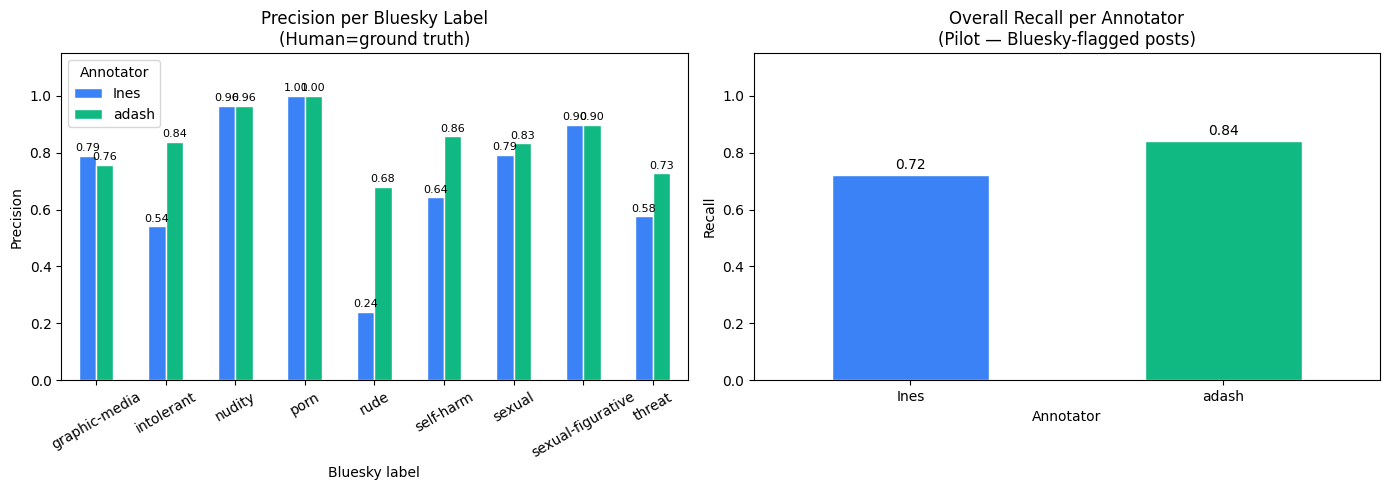

Saved → pilot_precision_per_label.csv


In [160]:
# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: precision per label per annotator
if len(prec_df):
    pivot = prec_df.pivot(
        index="Bluesky label", columns="Annotator", values="Precision"
    ).fillna(0)
    pivot.plot(kind="bar", ax=axes[0], color=["#3b82f6", "#10b981"], edgecolor="white")
    axes[0].set_title("Precision per Bluesky Label\n(Human=ground truth)")
    axes[0].set_ylabel("Precision")
    axes[0].set_ylim(0, 1.15)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="Annotator")
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.2f", fontsize=8, padding=2)

# Plot 2: recall bar
recall_df = pd.DataFrame(recall_rows)
recall_df.set_index("Annotator")["Recall"].plot(
    kind="bar", ax=axes[1], color=["#3b82f6", "#10b981"], edgecolor="white"
)
axes[1].set_title("Overall Recall per Annotator\n(Pilot — Bluesky-flagged posts)")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", fontsize=10, padding=2)

plt.tight_layout()
plt.savefig("pilot_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

# Save CSV
prec_df.to_csv("pilot_precision_per_label.csv", index=False)
print("Saved → pilot_precision_per_label.csv")

In [161]:
# How many pilot posts are in main_ann via combined_3k source tag
main_ann["source"] = main_ann["post_id"].map(
    lambda u: main_posts.get(u, {}).get("source", "unknown")
)

print("main_ann by source:")
print(
    main_ann.groupby(["annotator_name", "source"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)

# How many pilot_1k URIs are in main_ann
pilot_uris_in_main = set(pilot_posts.keys()) & set(main_ann["post_id"])
print(f"\npilot_1k URIs found in main_ann: {len(pilot_uris_in_main)}")

# How many are in combined_3k with source=pilot
combined_pilot_uris = {u for u, p in main_posts.items() if p.get("source") == "pilot"}
print(f"combined_3k URIs with source=pilot: {len(combined_pilot_uris)}")
print(
    f"Overlap between pilot_1k and combined_3k pilot: {len(combined_pilot_uris & set(pilot_posts.keys()))}"
)

main_ann by source:
source          ines_1k  pilot  sayeh_unlabeled
annotator_name                                 
Ines                264    272              264
adash               264    272              264
soumidas             33     34               33

pilot_1k URIs found in main_ann: 272
combined_3k URIs with source=pilot: 1000
Overlap between pilot_1k and combined_3k pilot: 1000


---
# Task 2 — Firehose 1K: Recall Post-Discussion

Using resolved labels from discussion. For posts still disagreed on (10 posts), we exclude them pending tiebreaker.

In [162]:
# Load post-discussion labels
disagree_df = pd.read_csv(DISAGREE_PATH)
disagree_df['Ines_label']  = disagree_df['Ines_label'].str.strip().str.capitalize()
disagree_df['adash_label'] = disagree_df['adash_label'].str.strip().str.capitalize()

resolved   = disagree_df[disagree_df['Ines_label'] == disagree_df['adash_label']]
still_dis  = disagree_df[disagree_df['Ines_label'] != disagree_df['adash_label']]
resolved_uris = set(resolved['uri'])
still_uris    = set(still_dis['uri'])

print(f"Originally disagreed: {len(disagree_df)}")
print(f"Resolved after discussion: {len(resolved)}")
print(f"Still disagreeing (excluded): {len(still_dis)}")

# Build updated lookups for firehose
# Override original labels with post-discussion resolved labels
fh_ann_clean = fh_ann.copy()
fh_ann_clean = fh_ann_clean[~fh_ann_clean['post_id'].isin(still_uris)]  # exclude unresolved

# For resolved posts, use the agreed-upon label
resolved_map = dict(zip(resolved['uri'], resolved['Ines_label']))  # same for both
for uri, lbl in resolved_map.items():
    fh_ann_clean.loc[fh_ann_clean['post_id']==uri, 'label'] = lbl

fh_ann_clean['bsky_flagged'] = fh_ann_clean['post_id'].map(
    lambda u: 'Unsafe' if fh_posts.get(u,{}).get('bluesky_labels') else 'Safe')

print(f"\nFirehose posts after excluding unresolved: {fh_ann_clean['post_id'].nunique()}")

print("\n=== FIREHOSE RECALL POST-DISCUSSION ===\n")
pr_rows = []
for name in ['Ines','adash']:
    sub = fh_ann_clean[fh_ann_clean['annotator_name']==name].copy()
    if len(sub) == 0: continue
    y_true = sub['label'].map({'Safe':0,'Unsafe':1}).values
    y_pred = sub['bsky_flagged'].map({'Safe':0,'Unsafe':1}).values
    p  = precision_score(y_true,y_pred,zero_division=0)
    r  = recall_score(y_true,y_pred,zero_division=0)
    f1 = f1_score(y_true,y_pred,zero_division=0)
    n_bsky  = y_pred.sum(); n_human = y_true.sum()
    n_both  = ((y_true==1)&(y_pred==1)).sum()
    n_only_human = ((y_true==1)&(y_pred==0)).sum()
    n_only_bsky  = ((y_true==0)&(y_pred==1)).sum()
    print(f"{name} (n={len(sub)}, excl. {len(still_dis)} unresolved):")
    print(f"  Bluesky flagged:  {n_bsky} ({100*n_bsky/len(sub):.1f}%)")
    print(f"  Human unsafe:     {n_human} ({100*n_human/len(sub):.1f}%)")
    print(f"  Both unsafe:      {n_both}")
    print(f"  Only human:       {n_only_human}  ← Bluesky missed these")
    print(f"  Only Bluesky:     {n_only_bsky}  ← False positives")
    print(f"  Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}\n")
    pr_rows.append({'Annotator':name,'n':len(sub),
                    'Precision':round(p,3),'Recall':round(r,3),'F1':round(f1,3),
                    'Human unsafe (%)':round(100*n_human/len(sub),1),
                    'Bluesky flagged (%)':round(100*n_bsky/len(sub),1)})

pd.DataFrame(pr_rows)


Originally disagreed: 31
Resolved after discussion: 21
Still disagreeing (excluded): 10

Firehose posts after excluding unresolved: 990

=== FIREHOSE RECALL POST-DISCUSSION ===

Ines (n=990, excl. 10 unresolved):
  Bluesky flagged:  6 (0.6%)
  Human unsafe:     20 (2.0%)
  Both unsafe:      6
  Only human:       14  ← Bluesky missed these
  Only Bluesky:     0  ← False positives
  Precision: 1.000  Recall: 0.300  F1: 0.462

adash (n=990, excl. 10 unresolved):
  Bluesky flagged:  6 (0.6%)
  Human unsafe:     20 (2.0%)
  Both unsafe:      6
  Only human:       14  ← Bluesky missed these
  Only Bluesky:     0  ← False positives
  Precision: 1.000  Recall: 0.300  F1: 0.462



,Annotator,n,Precision,Recall,F1,Human unsafe (%),Bluesky flagged (%)
0,Ines,990,1.0,0.3,0.462,2.0,0.6
1,adash,990,1.0,0.3,0.462,2.0,0.6


---
# Task 3 — AutoMod Export for Pushpdeep (Hive Analysis)

In [163]:
print("=== AUTOMOD ANNOTATIONS ===\n")
print(automod_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0).assign(
    total=lambda x: x.sum(axis=1),
    pct_unsafe=lambda x: (x.get('Unsafe',0)/x['total']*100).round(1)
).to_string())

# IAA between Ines and adash on automod
lu_am_ines  = build_lookup(automod_ann, 'Ines')
lu_am_adash = build_lookup(automod_ann, 'adash')
common_am   = sorted(set(lu_am_ines) & set(lu_am_adash))
la = [lu_am_ines[p] for p in common_am]
lb = [lu_am_adash[p] for p in common_am]
kappa = cohen_kappa_score(la,lb)
agree = sum(x==y for x,y in zip(la,lb))
print(f"\nAutomod IAA (n={len(common_am)}):")
print(f"  Agreement: {agree}/{len(common_am)} ({100*agree/len(common_am):.1f}%)")
print(f"  Cohen's κ: {kappa:.3f}")
print()
print(classification_report(la, lb, target_names=['Safe','Unsafe']))

# Majority / consensus label
rows = []
for p in common_am:
    post = automod_posts.get(p, {})
    consensus = lu_am_ines[p] if lu_am_ines[p]==lu_am_adash[p] else 'Disagree'
    imgs = post.get('images') or []
    img_url = imgs[0].get('file','') if imgs and isinstance(imgs[0],dict) else               post.get('image','')
    rows.append({
        'uri':            p,
        'text':           str(post.get('text',''))[:300],
        'Ines_label':     lu_am_ines[p],
        'adash_label':    lu_am_adash[p],
        'consensus':      consensus,
        'original_label': post.get('label',''),  # Bluesky label from file
        'image_url':      img_url,
    })
am_df = pd.DataFrame(rows)

print(f"\nConsensus breakdown:")
print(am_df['consensus'].value_counts().to_string())

# Save for Pushpdeep
am_df.to_csv('automod_for_hive.csv', index=False)
print(f"\nSaved {len(am_df)} rows → automod_for_hive.csv")
am_df.head()


=== AUTOMOD ANNOTATIONS ===

label           Safe  Unsafe  total  pct_unsafe
annotator_name                                 
Ines             241      47    288        16.3
adash            232      56    288        19.4

Automod IAA (n=288):
  Agreement: 257/288 (89.2%)
  Cohen's κ: 0.634

              precision    recall  f1-score   support

        Safe       0.95      0.92      0.93       241
      Unsafe       0.64      0.77      0.70        47

    accuracy                           0.89       288
   macro avg       0.80      0.84      0.82       288
weighted avg       0.90      0.89      0.90       288


Consensus breakdown:
consensus
Safe        221
Unsafe       36
Disagree     31

Saved 288 rows → automod_for_hive.csv


,uri,text,Ines_label,adash_label,consensus,original_label,image_url
0,at://did:plc:25krubja5rt6uzuns5ihfsra/app.bsky.feed.post/3loog4fbarc2t,,Unsafe,Unsafe,Unsafe,porn,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...
1,at://did:plc:26cwbhrythd3dghfalxpezxs/app.bsky.feed.post/3lnuvnz76p22q,,Safe,Safe,Safe,self-harm,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...
2,at://did:plc:26h2iiqioab23ojhlsjublao/app.bsky.feed.post/3lpozbheng225,,Safe,Safe,Safe,self-harm,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...
3,at://did:plc:27x2etibeg2dvwv7743dxlfx/app.bsky.feed.post/3lp5al6fjhk2e,,Safe,Unsafe,Disagree,porn,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...
4,at://did:plc:2cte4wipyk47qjujtxrskqcx/app.bsky.feed.post/3lp3b2og7xk23,,Safe,Safe,Safe,graphic-media,https://huggingface.co/datasets/ines-abdelaziz/neurips-content-moderation/re...


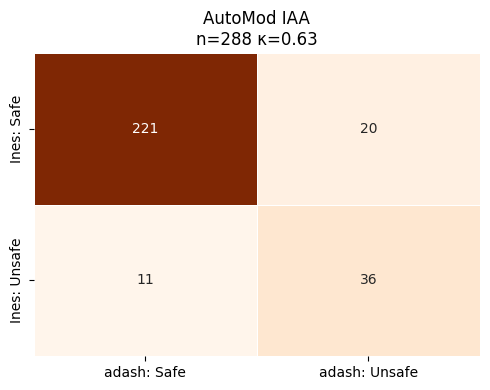

In [168]:
fig, ax = plt.subplots(figsize=(5, 4))

cats = ["Safe", "Unsafe"]
cm = confusion_matrix(la, lb, labels=cats)
sns.heatmap(
    pd.DataFrame(
        cm, index=[f"Ines: {c}" for c in cats], columns=[f"adash: {c}" for c in cats]
    ),
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=ax,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title(f"AutoMod IAA\nn={len(common_am)} κ={kappa:.2f}")
plt.tight_layout()
plt.savefig("automod_stats.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import json, pandas as pd
from pathlib import Path
from huggingface_hub import HfApi

TOKEN = ""  # Insert your HF token here
UPLOAD = Path(".")

# Load annotations
ann = pd.read_csv("Bluesky Moderation Annotations.csv")  # update the file with the latest version of annotations
ann.columns = ann.columns.str.strip()
ann = ann.drop_duplicates(subset=['annotator_name','post_id'], keep='last')

# Main survey only (display_num < 10000) — both Ines and adash
main_ann = ann[ann['display_num'] < 10000].copy()

# Pilot remaining (display_num 20000-30000)
pilot_rem_ann = ann[(ann['display_num'] >= 20000) & (ann['display_num'] < 30000)].copy()

# Combine both
combined = pd.concat([main_ann, pilot_rem_ann], ignore_index=True)

# Build lookups
lu_ines  = dict(zip(combined[combined['annotator_name']=='Ines']['post_id'],
                    combined[combined['annotator_name']=='Ines']['label']))
lu_adash = dict(zip(combined[combined['annotator_name']=='adash']['post_id'],
                    combined[combined['annotator_name']=='adash']['label']))

# Find posts labeled by both where source is pilot
# Load combined_3k to get source info
main_posts = {}
with open(UPLOAD / "combined_3k.jsonl") as f:
    for line in f:
        if line.strip():
            p = json.loads(line)
            if p.get('uri'): main_posts[p['uri']] = p

# Also load pilot_1k for pilot post metadata
pilot_posts = {}
with open(UPLOAD / "pilot_1k.jsonl") as f:
    for line in f:
        if line.strip():
            p = json.loads(line)
            if p.get('uri'): pilot_posts[p['uri']] = p

# Load pilot_remaining
pilot_rem_posts = {}
with open(UPLOAD / "pilot_remaining.jsonl") as f:
    for line in f:
        if line.strip():
            p = json.loads(line)
            if p.get('uri'): pilot_rem_posts[p['uri']] = p

all_pilot_posts = {**pilot_posts, **pilot_rem_posts}
print(f"Total pilot posts: {len(all_pilot_posts)}")

# Find pilot disagreements (Ines vs adash)
common = set(lu_ines) & set(lu_adash)
pilot_common = [p for p in common if p in all_pilot_posts]
pilot_disagree = [p for p in pilot_common if lu_ines[p] != lu_adash[p]]

print(f"Pilot posts labeled by both: {len(pilot_common)}")
print(f"Pilot disagreements: {len(pilot_disagree)}")

# Get reasons and categories
cats_ines  = dict(zip(combined[combined['annotator_name']=='Ines']['post_id'],
                      combined[combined['annotator_name']=='Ines']['unsafe_categories'].fillna('')))
cats_adash = dict(zip(combined[combined['annotator_name']=='adash']['post_id'],
                      combined[combined['annotator_name']=='adash']['unsafe_categories'].fillna('')))

# Build JSONL
out_rows = []
for uri in pilot_disagree:
    post = dict(all_pilot_posts[uri])
    post['ines_label']       = lu_ines[uri]
    post['adash_label']      = lu_adash[uri]
    post['ines_categories']  = cats_ines.get(uri, '')
    post['adash_categories'] = cats_adash.get(uri, '')
    post['source']           = 'pilot_disagree'
    out_rows.append(post)

print(f"\nBuilding JSONL with {len(out_rows)} posts")
print(f"Ines→Unsafe, adash→Safe: {sum(1 for u in pilot_disagree if lu_ines[u]=='Unsafe')}")
print(f"Ines→Safe, adash→Unsafe: {sum(1 for u in pilot_disagree if lu_adash[u]=='Unsafe')}")

out_path = UPLOAD / "data/pilot_disagreements.jsonl"
with open(out_path, 'w') as f:
    for p in out_rows:
        f.write(json.dumps(p, ensure_ascii=False) + '\n')
print(f"Saved → {out_path}")

# Upload
api = HfApi(token=TOKEN)
api.upload_file(
    path_or_fileobj=str(out_path),
    path_in_repo="data/pilot_disagreements.jsonl",
    repo_id="ines-abdelaziz/neurips-content-moderation",
    repo_type="dataset",
    token=TOKEN,
)
print("Uploaded to HF!")

Total pilot posts: 1000
Pilot posts labeled by both: 355
Pilot disagreements: 72

Building JSONL with 72 posts
Ines→Unsafe, adash→Safe: 17
Ines→Safe, adash→Unsafe: 55
Saved → data/pilot_disagreements.jsonl
Uploaded to HF!
